<a href="https://colab.research.google.com/github/jhenningsen/Equity_Analysis/blob/main/Leverage_ETFs/Log_Trend_Estimator.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ticker Price Prediction and Regression Analysis

This notebook performs a linear regression analysis on a user-defined ticker symbol's historical price data to predict future prices. It includes:

*   **Parameterized Ticker Input:** The `TICKER_SYMBOL` can be easily changed to analyze different assets.
*   **Data Acquisition:** Downloads historical 'Close' prices using `yfinance`.
*   **Logarithmic Transformation:** Applies a natural logarithm to prices for linear regression, assuming a multiplicative trend.
*   **Linear Regression Model:** Fits a linear model to the logarithm of prices over time.
*   **Regression Metrics:** Calculates and displays R-squared, Mean Absolute Error (MAE), and Root Mean Squared Error (RMSE) to evaluate model fit.
*   **Future Price Prediction:** Predicts the dollar price for 30, 60, and 90 days into the future.
*   **Prediction Range with Likelihood:** Provides a range for the future price predictions based on the RMSE and a statistical likelihood of the actual price falling within this range (assuming normally distributed errors).

## Parameterized Ticker Configuration

In [130]:
TICKER_SYMBOL = "UVXY" # @param {type:"string"}

print(f"Using ticker symbol: {TICKER_SYMBOL}")

Using ticker symbol: UVXY


In [131]:
# Import necessary libraries

import numpy as np
import pandas as pd
import yfinance as yf
from sklearn.mixture import GaussianMixture
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display # Ensure display is available
from ipywidgets import interact, FloatSlider



In [132]:
# Clear all DataFrames from memory
import gc

# Get a list of all variables in the global namespace
all_vars = list(globals().keys())

# Identify and delete pandas DataFrames
for var_name in all_vars:
    if isinstance(globals()[var_name], pd.DataFrame):
        del globals()[var_name]
        print(f"Deleted DataFrame: {var_name}")

# Run garbage collector to free up memory
gc.collect()

print("All DataFrames cleared from memory.")

Deleted DataFrame: ticker_data
Deleted DataFrame: regression_df
Deleted DataFrame: X
Deleted DataFrame: X_future
All DataFrames cleared from memory.


In [133]:
# Download TQQQ data
tickers = [TICKER_SYMBOL]
ticker_data = yf.download(tickers, start="2022-01-01", end=pd.Timestamp.now(), auto_adjust=True)['Close'].dropna()

# Convert to DataFrame if it's a Series (ensure ticker_data is a DataFrame for subsequent operations)
if isinstance(ticker_data, pd.Series):
    ticker_data = ticker_data.to_frame(name=TICKER_SYMBOL)

# Calculate TQQQ returns and create benchmark equity
ticker_data[f'{TICKER_SYMBOL}_Return'] = ticker_data[TICKER_SYMBOL].pct_change()

# Create a copy for regression analysis and to serve as the consistent base for all strategies
regression_df = ticker_data.copy()

# Calculate Standard_Benchmark_Equity once here to be used across all strategies
initial_portfolio_value_benchmark = 100000.0
# Use fillna(1) for the first return to correctly initialize cumprod for the benchmark
regression_df['Standard_Benchmark_Equity'] = (1 + regression_df[f'{TICKER_SYMBOL}_Return']).fillna(1).cumprod() * initial_portfolio_value_benchmark

print(f"\n{TICKER_SYMBOL} data and Benchmark Equity prepared.")

[*********************100%***********************]  1 of 1 completed


UVXY data and Benchmark Equity prepared.


## Calculate Logarithmic Regression

In [134]:
# Calculate log price, trend line, and residuals
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

regression_df[f'{TICKER_SYMBOL}_Log_Price'] = np.log(regression_df[TICKER_SYMBOL])
regression_df['Days_Since_Start'] = np.arange(len(regression_df))
X = regression_df[['Days_Since_Start']]
y = regression_df[f'{TICKER_SYMBOL}_Log_Price']
model = LinearRegression()
model.fit(X, y)
regression_df[f'{TICKER_SYMBOL}_Trend_Line'] = model.predict(X)
regression_df[f'{TICKER_SYMBOL}_Residuals'] = regression_df[f'{TICKER_SYMBOL}_Log_Price'] - regression_df[f'{TICKER_SYMBOL}_Trend_Line']

print(f"{TICKER_SYMBOL} Log Price, Trend Line, and Residuals calculated and added to regression_df.")

# Calculate and display regression fit metrics
y_pred = model.predict(X)
r_squared = r2_score(y, y_pred)
mae = mean_absolute_error(y, y_pred)
rmse = np.sqrt(mean_squared_error(y, y_pred))

print(f"\n--- Linear Regression Fit Metrics for {TICKER_SYMBOL} ---")
print(f"R-squared: {r_squared:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")

UVXY Log Price, Trend Line, and Residuals calculated and added to regression_df.

--- Linear Regression Fit Metrics for UVXY ---
R-squared: 0.9420
Mean Absolute Error (MAE): 0.3192
Root Mean Squared Error (RMSE): 0.3757


Now, let's visualize the log price, the linear regression trend line, and the residuals. This will help us understand the deviations from the trend.

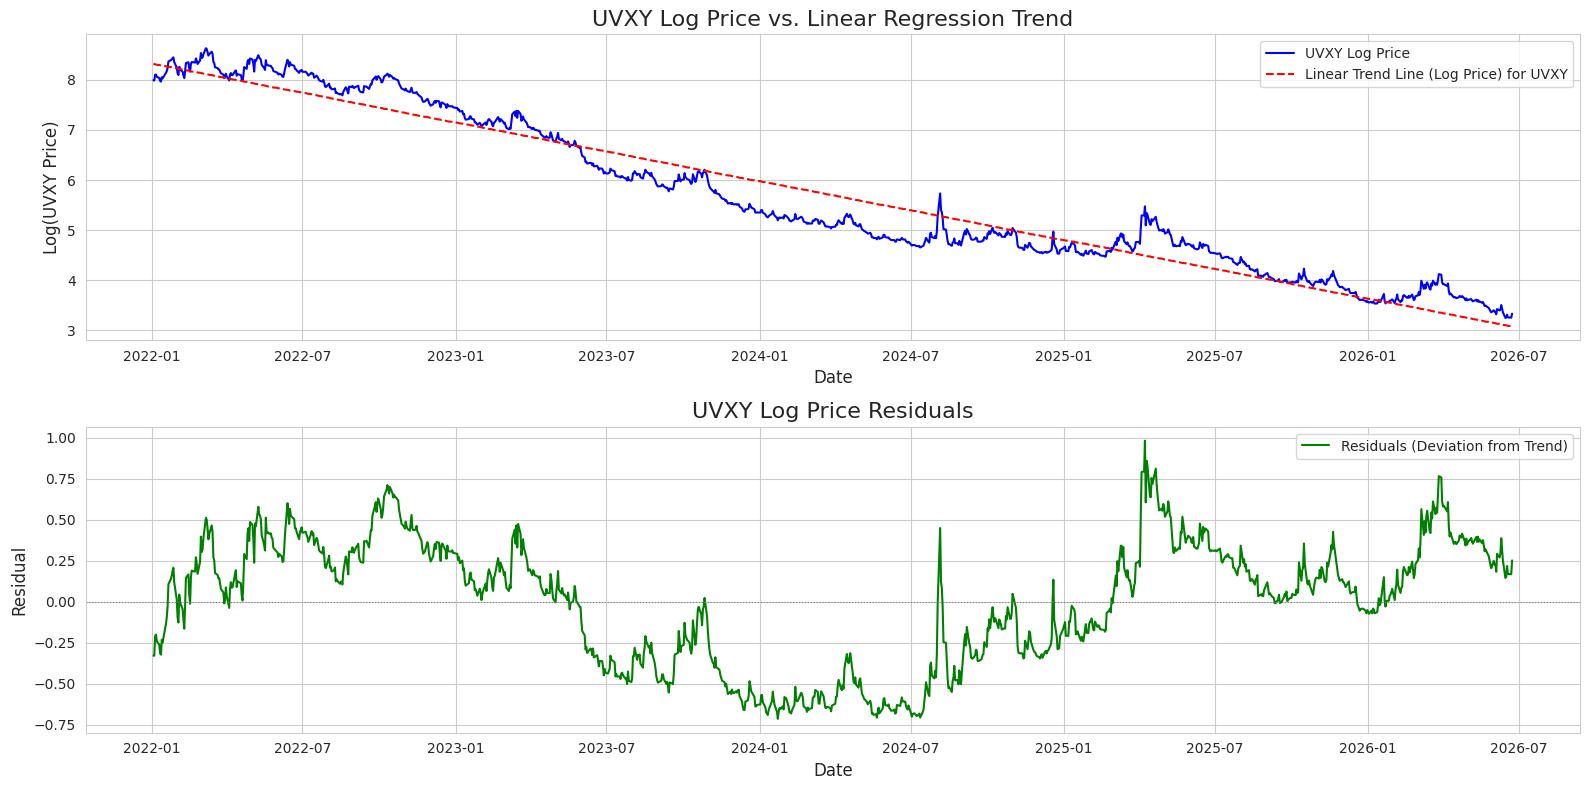

In [135]:
# Plot TQQQ log price, trend, and residuals
plt.figure(figsize=(16, 8))

# Plot Log Price and Trend Line
plt.subplot(2, 1, 1) # 2 rows, 1 column, first plot
plt.plot(regression_df.index, regression_df[f'{TICKER_SYMBOL}_Log_Price'], label=f'{TICKER_SYMBOL} Log Price', color='blue')
plt.plot(regression_df.index, regression_df[f'{TICKER_SYMBOL}_Trend_Line'], label=f'Linear Trend Line (Log Price) for {TICKER_SYMBOL}', color='red', linestyle='--')
plt.title(f'{TICKER_SYMBOL} Log Price vs. Linear Regression Trend', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel(f'Log({TICKER_SYMBOL} Price)', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True)

# Plot Residuals
plt.subplot(2, 1, 2) # 2 rows, 1 column, second plot
plt.plot(regression_df.index, regression_df[f'{TICKER_SYMBOL}_Residuals'], label='Residuals (Deviation from Trend)', color='green')
plt.axhline(0, color='gray', linestyle=':', linewidth=0.8)
plt.title(f'{TICKER_SYMBOL} Log Price Residuals', fontsize=16)
plt.xlabel('Date', fontsize=12)
plt.ylabel('Residual', fontsize=12)
plt.legend(fontsize=10)
plt.grid(True)

plt.tight_layout()
plt.show()

In [136]:
# Predict ticker price in dollars for 30, 60, and 90 days from now

# Get the last 'Days_Since_Start' from the regression_df
last_days_since_start = regression_df['Days_Since_Start'].iloc[-1]

# Calculate future 'Days_Since_Start' values
future_days = np.array([30, 60, 90])
future_days_since_start = last_days_since_start + future_days

# Prepare data for prediction (reshape to 2D array)
X_future = pd.DataFrame(future_days_since_start, columns=['Days_Since_Start'])

# Predict future log prices using the trained model
predicted_log_prices = model.predict(X_future)

# Convert predicted log prices back to dollar prices (np.exp is the inverse of np.log)
predicted_dollar_prices = np.exp(predicted_log_prices)

# Get current date and price
current_date = pd.Timestamp.now().strftime('%Y-%m-%d')
current_price = ticker_data[TICKER_SYMBOL].iloc[-1]

predicted_log_prices_lower_bound = predicted_log_prices - rmse
predicted_log_prices_upper_bound = predicted_log_prices + rmse

predicted_dollar_prices_lower_bound = np.exp(predicted_log_prices_lower_bound)
predicted_dollar_prices_upper_bound = np.exp(predicted_log_prices_upper_bound)

print(f"--- Current {TICKER_SYMBOL} Information ({current_date}) ---")
print(f"Current Price: ${current_price:.2f}")
print(f"\n--- Predicted {TICKER_SYMBOL} Prices ---")
for i, days in enumerate(future_days):
    print(f"{days} days from now: ${predicted_dollar_prices[i]:.2f} (Range: ${predicted_dollar_prices_lower_bound[i]:.2f} - ${predicted_dollar_prices_upper_bound[i]:.2f})")

print(f"\nStatistical Likelihood: Assuming normally distributed errors, there's approximately a 31.7% chance that the actual price will fall outside this range (i.e., a 68.3% chance it falls within this range).")


--- Current UVXY Information (2026-06-23) ---
Current Price: $28.00

--- Predicted UVXY Prices ---
30 days from now: $18.91 (Range: $12.99 - $27.53)
60 days from now: $16.43 (Range: $11.28 - $23.92)
90 days from now: $14.28 (Range: $9.81 - $20.79)

Statistical Likelihood: Assuming normally distributed errors, there's approximately a 31.7% chance that the actual price will fall outside this range (i.e., a 68.3% chance it falls within this range).
